In [1]:
# Import
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import os

plt.style.use('seaborn-v0_8')  # Clean plots

In [10]:
# Load simulated data
file = "../data/simulated/glass.npz"
data = np.load(file)
vibration = data['vibration']
sample_rate = int(data['sample_rate_hz'])
material = str(data['material'])

print(f"Loaded {material} tap ({len(vibration)} samples)")

Loaded glass tap (2000 samples)


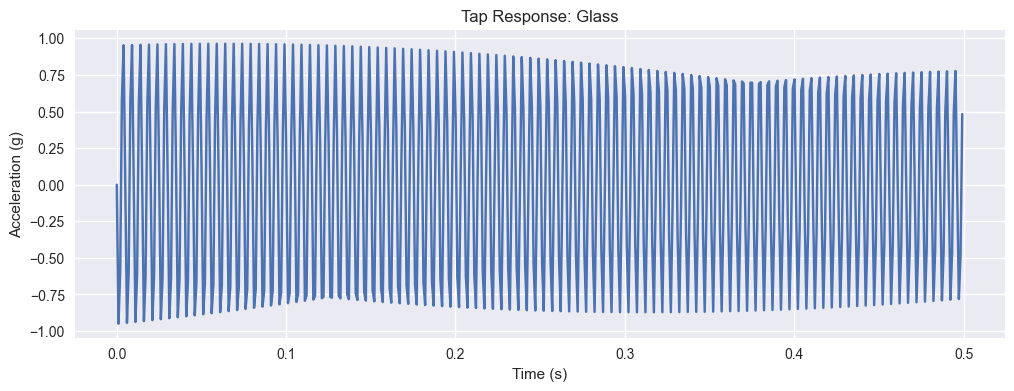

In [11]:
# Plot time-domain signal
plt.figure(figsize=(12, 4))
time = np.linspace(0, len(vibration)/sample_rate, len(vibration))
plt.plot(time[:500], vibration[:500])  # First 0.5 sec
plt.title(f"Tap Response: {material.title()}")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.grid(True)
plt.show()

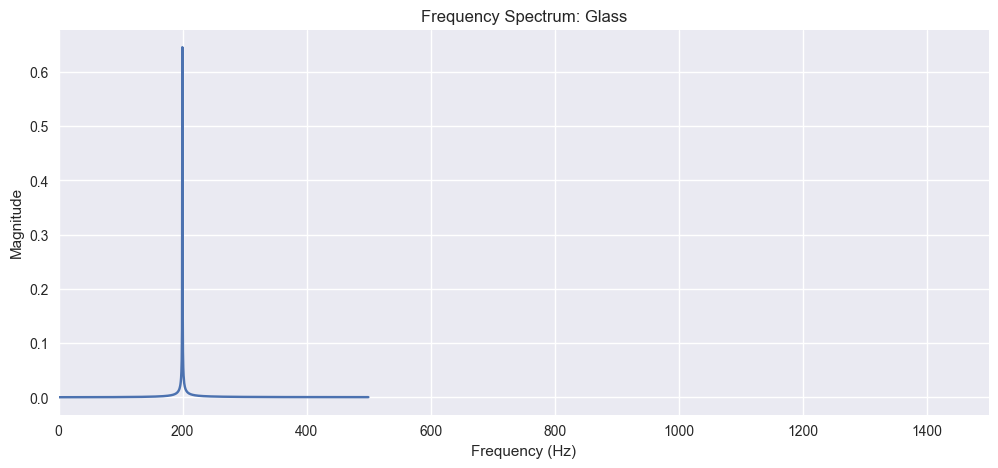

🔧 Dominant frequency: 199.5 Hz


In [12]:
# FFT: Frequency Domain
N = len(vibration)
yf = fft(vibration)
xf = fftfreq(N, 1/sample_rate)[:N//2]

plt.figure(figsize=(12, 5))
plt.plot(xf, 2.0/N * np.abs(yf[:N//2]))
plt.title(f"Frequency Spectrum: {material.title()}")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.xlim(0, 1500)
plt.show()

# Find peak frequency
peak_freq = xf[np.argmax(np.abs(yf[:N//2]))]
print(f"🔧 Dominant frequency: {peak_freq:.1f} Hz")

## 🔍 Try Another Material
Change the filename to `wood.npz`, `metal.npz`, or `plastic.npz` and re-run!